In [1]:
import os
import io
import gc
import pandas as pd
from PIL import Image
from transformers import pipeline, BitsAndBytesConfig
from datasets import load_dataset
import torch

1) Dodanie etykiet przy pomocy llm'a: pobiera z huggingface (https:
//huggingface.co/datasets/wikimedia/wit_base) jedną z paczek ze zdjęciami, dodaje etykiety -> dzieli do odpowiednich folderów (0 - gdy zdjęcie zrobione w środku, 1 - gdy zdjęcie zrobione na zewnątrz), które są na dysku.

2) Pobiera zdjęcia z etykietami z folderów z dysku. Dane są średnio zbalansowane w tych 5000 zdjęciach jest około 3600 klasy 1 i 1400 klasy 0. Potem do zrobienia klasyfikatora używam transfer learningu - inception_v3.

3) Pobiera zbiorek testowy z linku ('https://home.ipipan.waw.pl/sj/AdvML/Wikimedia_project/test_set.tgz') i na jego podstawie tworzy wektor predykcji i go zapisuje.


In [ ]:
size = 5000

# Konfiguracja folderów
base_dir = 'content'
os.makedirs(f"{base_dir}/1", exist_ok=True)
os.makedirs(f"{base_dir}/0", exist_ok=True)
csv_path = f"{base_dir}/moj_zbior_danych.csv"

HF_TOKEN = os.environ.get("HF_TOKEN")

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16
)

# Inicjalizacja modelu
pipe = pipeline(
    "image-text-to-text",
    model="google/gemma-3-4b-it",
    device_map="auto",
    token=HF_TOKEN,
    model_kwargs={
        "quantization_config": quantization_config

    }
)

system_prompt = "You are a highly accurate image classification assistant."
user_prompt = (
    "Analyze this image. Is it a photograph of an outdoor location like a park, street, or forest? "
    "Reply 1 only if it is a real-world outdoor photograph. "
    "Reply 0 if it is inside, a graphic, a drawing, a map, a painting, or a diagram. "
    "Do not output any other text."
)

# Wznawianie
if os.path.exists(csv_path):
    df_existing = pd.read_csv(csv_path)
    generated_labels = df_existing["etykieta"].tolist()
    image_urls = df_existing["sciezka_do_pliku"].tolist()
else:
    generated_labels = []
    image_urls = []

# Wczytywanie danych
dataset = load_dataset(
    "wikimedia/wit_base",
    data_files="data/train-00000-of-00330.parquet",
    split="train",
    streaming=True
)

if len(image_urls) > 0:
    dataset = dataset.skip(len(image_urls))

dataset_iter = iter(dataset)

# Pętla główna
for i in range(len(image_urls), size):
    try:
        row = next(dataset_iter)
        img_data = row['image']

        if isinstance(img_data, dict) and 'bytes' in img_data:
            image = Image.open(io.BytesIO(img_data['bytes'])).convert("RGB")
        elif isinstance(img_data, bytes):
            image = Image.open(io.BytesIO(img_data)).convert("RGB")
        else:
            image = img_data.convert("RGB")

        messages = [
            {"role": "system", "content": [{"type": "text", "text": system_prompt}]},
            {"role": "user", "content": [{"type": "image", "image": image}, {"type": "text", "text": user_prompt}]}
        ]

        output = pipe(messages, max_new_tokens=2)
        response = output[0]["generated_text"][-1]["content"].strip()
        label = 1 if "1" in response else 0

        # Zapis pliku
        save_path = f"{base_dir}/{label}/image_{i}.jpg"
        image.save(save_path)

        generated_labels.append(label)
        image_urls.append(save_path)

        if i % 10 == 0:
            pd.DataFrame({
                "sciezka_do_pliku": image_urls,
                "etykieta": generated_labels
            }).to_csv(csv_path, index=False)
            print(f"Zapisano: {i+1}/{size}")

        if i % 50 == 0:
            torch.cuda.empty_cache()
            gc.collect()

        del image, messages, output, response, row

    except StopIteration:
        break
    except Exception as e:
        print(f"Błąd przy zdjęciu nr {i}: {e}")

# Finalny zapis
pd.DataFrame({"sciezka_do_pliku": image_urls, "etykieta": generated_labels}).to_csv(csv_path, index=False)

### Model

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
import numpy as np
from tqdm.notebook import tqdm
import os
from PIL import Image

In [3]:
# Wybór urządzenia
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"{device}")

base_dir = 'content/'

# Transformacje
vw = torchvision.models.get_model_weights("inception_v3")
preproc = vw.DEFAULT.transforms()

# Wczytanie danych
dataset = ImageFolder(root=base_dir, transform=preproc)

# Podział na zbiór treningowy i walidacyjny
num_samples = len(dataset)
indices = list(range(num_samples))
np.random.seed(123)
np.random.shuffle(indices)

split_point = int(0.8 * num_samples)
train_dataset = Subset(dataset, indices[:split_point])
test_dataset = Subset(dataset, indices[split_point:])

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

cpu


In [4]:
for i in range(20):
    print(train_dataset[i][0].shape, train_dataset[i][1])

torch.Size([3, 299, 299]) 1
torch.Size([3, 299, 299]) 1
torch.Size([3, 299, 299]) 1
torch.Size([3, 299, 299]) 1
torch.Size([3, 299, 299]) 1
torch.Size([3, 299, 299]) 1
torch.Size([3, 299, 299]) 1
torch.Size([3, 299, 299]) 0
torch.Size([3, 299, 299]) 1
torch.Size([3, 299, 299]) 1
torch.Size([3, 299, 299]) 2
torch.Size([3, 299, 299]) 0
torch.Size([3, 299, 299]) 1
torch.Size([3, 299, 299]) 1
torch.Size([3, 299, 299]) 0
torch.Size([3, 299, 299]) 0
torch.Size([3, 299, 299]) 1
torch.Size([3, 299, 299]) 1
torch.Size([3, 299, 299]) 0
torch.Size([3, 299, 299]) 1


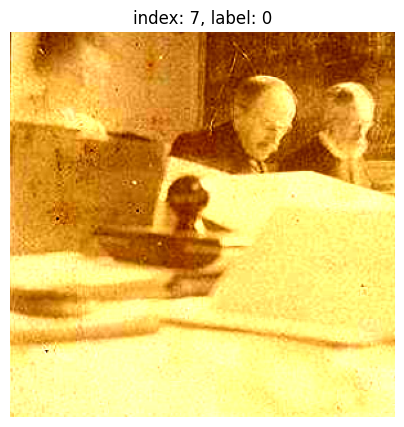

In [5]:
import matplotlib.pyplot as plt

# Change this index
idx = 7

img, label = train_dataset[idx]

# Convert CHW -> HWC for matplotlib
img_vis = img.permute(1, 2, 0)

plt.figure(figsize=(5, 5))
plt.imshow(img_vis)
plt.axis("off")
plt.title(f"index: {idx}, label: {label}")
plt.show()

In [6]:
def eval_net(net, dataloader):
    net.eval()
    with torch.no_grad():
        acc_sum = 0
        n = 0
        for X, y in tqdm(dataloader, leave=False, desc="Walidacja"):
            X = X.to(device)
            y = y.to(device).float()

            pred = net(X).squeeze(-1)

            predicted = (torch.sigmoid(pred)> 0.5).float()

            acc_sum += (predicted == y).sum().item()
            n += X.shape[0]

    return acc_sum / n

In [7]:
def fit(net, train=train_dataloader, valid=test_dataloader, epochs=5, lr=None):
    net = net.to(device)

    if lr is None:
        optimizer = optim.Adam(net.parameters())
    else:
        optimizer = optim.Adam(net.parameters(), lr=lr)

    waga = torch.tensor([0.3]).to(device)
    loss = torch.nn.BCEWithLogitsLoss(pos_weight=waga)
    #loss = torch.nn.BCEWithLogitsLoss()

    for e in range(epochs):
        if next(net.parameters()).requires_grad == False:
            net.eval()
            net.fc.train()
        else:
            net.train()

        for X, y in tqdm(train, desc=f"Epoka {e}"):
            optimizer.zero_grad()
            X = X.to(device)
            y = y.to(device).float()

            pred = net(X)

            if isinstance(pred, tuple):
                pred = pred[0]

            pred = pred.squeeze(-1)

            l = loss(pred, y)
            l.backward()
            optimizer.step()

        if valid is not None:
            accuracy = eval_net(net, valid)
            print(f"Accuracy {e} : {accuracy:.4f}")

In [ ]:
net = torchvision.models.get_model("inception_v3", weights="DEFAULT")
net.aux_logits = False
net.to(device)

# Warstwa górna
in_features = net.fc.in_features
net.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 1)
).to(device)

# Trenowanie nowej warstwy
net.eval()
net.requires_grad_(False)
net.fc.requires_grad_(True)
net.fc.train()


fit(net, epochs=5)

# # Trenowanie całej sieci
# net.requires_grad_(True)
# _ = net.train()

# fit(net, epochs=5, lr=1e-4)

# Zapis
torch.save(net.state_dict(), 'content/model.pth')

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /home/janek/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:10<00:00, 10.7MB/s] 


Epoka 0:   0%|          | 0/138 [00:00<?, ?it/s]

Walidacja:   0%|          | 0/35 [00:00<?, ?it/s]

Accuracy 0 : 0.7275


Epoka 1:   0%|          | 0/138 [00:00<?, ?it/s]

Walidacja:   0%|          | 0/35 [00:00<?, ?it/s]

### Predykcje

In [ ]:
import os
import tarfile
import urllib.request

url = 'https://home.ipipan.waw.pl/sj/AdvML/Wikimedia_project/test_set.tgz'
test_set_path = 'content/test_set'

# Pobieranie pliku
if not os.path.exists(test_set_path):
    urllib.request.urlretrieve(url, 'test_set.tgz')

    # Rozpakowanie
    with tarfile.open('test_set.tgz', 'r:gz') as tar:
        tar.extractall(path='content/')

In [ ]:
net = torchvision.models.get_model("inception_v3", weights=None)
net.aux_logits = False

in_features = net.fc.in_features
net.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 1)
)
net.to(device)

# Wczytanie wag
net.load_state_dict(torch.load('content/model.pth', map_location=device))
net.eval()

vw = torchvision.models.get_model_weights("inception_v3")
preproc = vw.DEFAULT.transforms()


# Generowanie pliku
image_files = sorted([f for f in os.listdir(test_set_path) if f.endswith(('.jpg', '.png', '.jpeg'))])

with open('wyniki.txt', 'w') as f:
    f.write('333085\n')

    for img_name in tqdm(image_files, desc="Generowanie predykcji"):
        img_path = os.path.join(test_set_path, img_name)

        # Wczytanie obrazu
        with Image.open(img_path).convert('RGB') as img:
            input_tensor = preproc(img).unsqueeze(0).to(device)

        # Predykcja
        with torch.no_grad():
            output = net(input_tensor)

            probability = torch.sigmoid(output).squeeze(-1).item()

            prediction = 1 if probability > 0.5 else 0

        f.write(f'{img_name}\t{prediction}\n')

Generowanie predykcji:   0%|          | 0/500 [00:00<?, ?it/s]

In [ ]:
from google.colab import files
files.download('wyniki.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>